In [72]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re

# IOB Fits


Reading from configuration file: conf/iob_6.ini

Target: A

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 32 34 36 37 38 39 40 41 42 43 45 46 47 48 49 50 52 54]

Equation requested:
(0.101915 + (0.981869 * (((((((18.352127 * X9) - ((-74.840126) * X1)) + (54.567383 * X2)) / (sqrt(1 + ((25.086458 * X9) - 9.698587) ^ 2))) / (sqrt(1 + (((4.385856 * X9) - 3.134392) ^ 2) ^ 2))) + ((-3.267232) * X1)) - ((((-3059.672607) * X8) - (((163.182144 * X1) + (596.445190 * X7)) - (-15.086555))) / exp(((3.152609 * X9) ^ 2))))))

Equation with pars
-3.207993816608*IOB1 - 0.981869*(-163.182144*IOB1 - 596.44519*IOB7 - 3059.672607*IOB8 - 15.086555)*exp(-9.938943506881*lam**2) + 0.101915 + 0.981869*(74.840126*IOB1 + 54.567383*IOB2 + 18.352127*lam)/(sqrt((4.385856*lam - 3.134392)**4 + 1)*sqrt((25.086458*lam - 9.698587)**2 + 1))

Converted equation:
-c0*IOB1 - c1*(-c2*IOB1 - c3*IOB7 - c4*IOB8 - c5)*exp(-c6*lam**2) + c7 + c8*(c9*IOB1 + c10*IOB2 + c11*lam)/(s

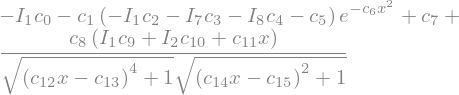


Latex version:
- I_{1} c_{0} - c_{1} \left(- I_{1} c_{2} - I_{7} c_{3} - I_{8} c_{4} - c_{5}\right) e^{- c_{6} x^{2}} + c_{7} + \frac{c_{8} \left(I_{1} c_{9} + I_{2} c_{10} + c_{11} x\right)}{\sqrt{\left(c_{12} x - c_{13}\right)^{4} + 1} \sqrt{\left(c_{14} x - c_{15}\right)^{2} + 1}}

Value at x=1:


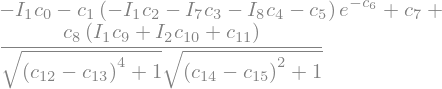


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 20
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2', 'IOB7', 'IOB8']
Final number of parameters: 10
Of which global: 7 and local: 3
Final values: [4.385856, -9.93894350688100, 18.352127, 25.086458, -3.13439200000000, -9.69858700000000, 0.981869]
Local replacements: {B0: -IOB1*c0 + c7, B1: -c1*(-IOB1*c2 - IOB7*c3 - IOB8*c4 - c5), B2: IOB1*c9 + IOB2*c10}


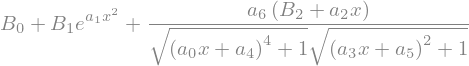


Latex version:
B_{0} + B_{1} e^{a_{1} x^{2}} + \frac{a_{6} \left(B_{2} + a_{2} x\right)}{\sqrt{\left(a_{0} x + a_{4}\right)^{4} + 1} \sqrt{\left(a_{3} x + a_{5}\right)^{2} + 1}}

Value at x=1:


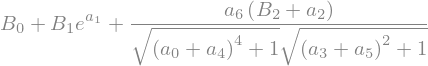

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_6.ini

Target: A


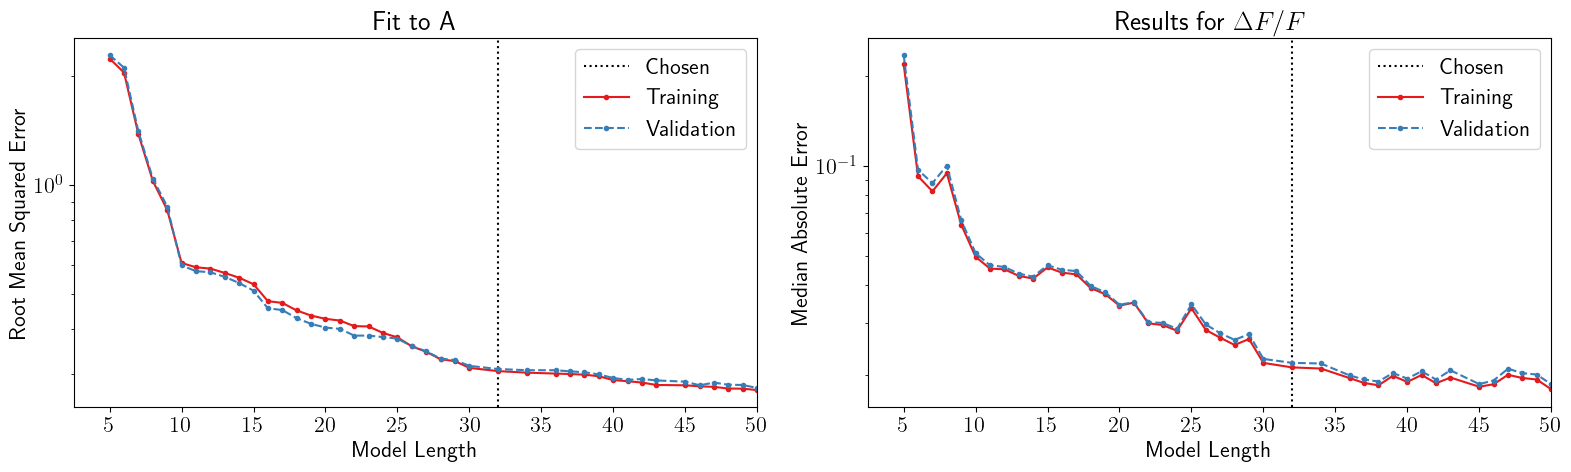

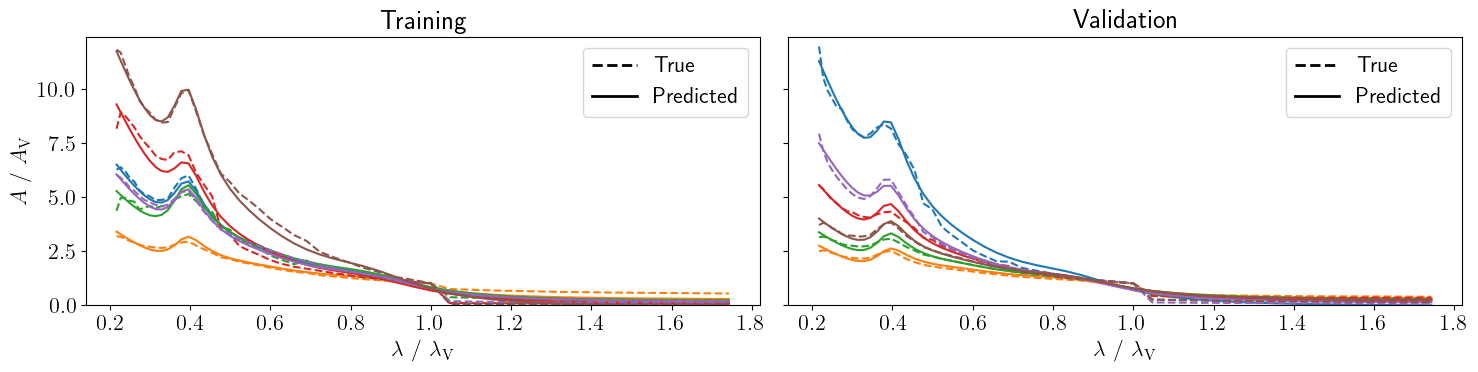

In [73]:
ini_file = 'conf/iob_1.ini'; ilen = 72
ini_file = 'conf/iob_2.ini'; ilen = 51
ini_file = 'conf/iob_3.ini'; ilen = 32
# ini_file = 'conf/iob_4.ini'; ilen = 30
ini_file = 'conf/iob_6.ini'; ilen = 32 # quite simple -> rerunning as iob_10 with 24 hours
# ini_file = 'conf/iob_7.ini'; ilen = 27
# ini_file = 'conf/iob_8.ini'; ilen = 32 # not very good
# ini_file = 'conf/iob_9.ini'; ilen = 28
# ini_file = 'conf/iob_10.ini'; ilen = 34
# ilen = 32
# ini_file = 'conf/iob_11.ini'; ilen = None
# ini_file = 'conf/iob_12.ini'; ilen = 31
# ini_file = 'conf/iob_13.ini'; ilen = None
# ini_file = 'conf/iob_14.ini'; ilen = 29
# ilen = None
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
# processing_fun.prediction_plots(ini_file, ilen=ilen);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6, offset=24, plot_av_diff=False, plot_dF_F=False);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_6.ini
1.1562242401210138e-06
0.6440796931067786


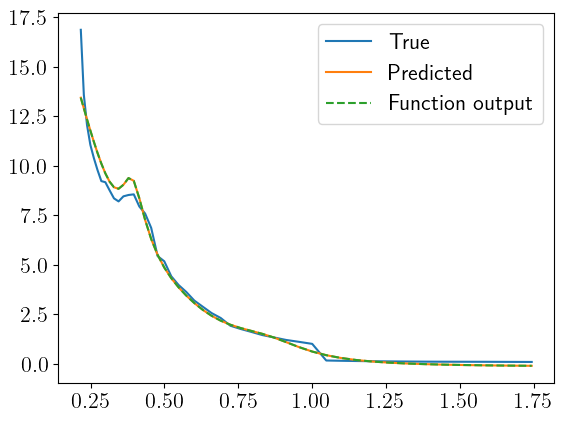

In [70]:
name = 'train'
ini_file = 'conf/iob_6.ini'; ilen = 32

all_data = pd.read_csv('../data/gal_los_iobcomp_attcurve_galprop.dat', sep='\t')
matches = pd.read_csv(f'../symbolic_regression/data/iob_data_10/iob_{name}_galaxy_ids_los.txt', sep='\t',)
matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
data_train = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
fit_data = pd.read_csv("../data/galaxy_optimization_results.csv")
fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
data_train = data_train.merge(fit_data, on=['galaxy_id', 'los'], how='inner')

# Get AV
attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ytrue = data[:,args.npar+1]
ypred = data[:,args.npar+2]
if args.fit_log:
    ypred = 10. ** ypred
    ytrue = 10. ** ytrue
fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(lam))
ytrue = ytrue.reshape(-1, len(lam))

for i in [4]:
    gal_id = matches['galaxy_id'].values[i]
    los = matches['los'].values[i]
    row = data_train[(data_train['galaxy_id'] == gal_id) & (data_train['los'] == los)]
    iob_cols = sorted([col for col in row.columns if re.match(r'IOB\d+', col)])
    IOB = row[iob_cols].values[0]
    B = sr_fun.compute_initial_B(IOB)
    new_pred = sr_fun.compute_Av(lam, *B)

    plt.plot(lam, ytrue[i], label='True')
    plt.plot(lam, ypred[i], label='Predicted')
    plt.plot(lam, new_pred, label='Function output', ls='--')
    plt.legend()

    print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
    print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values



# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


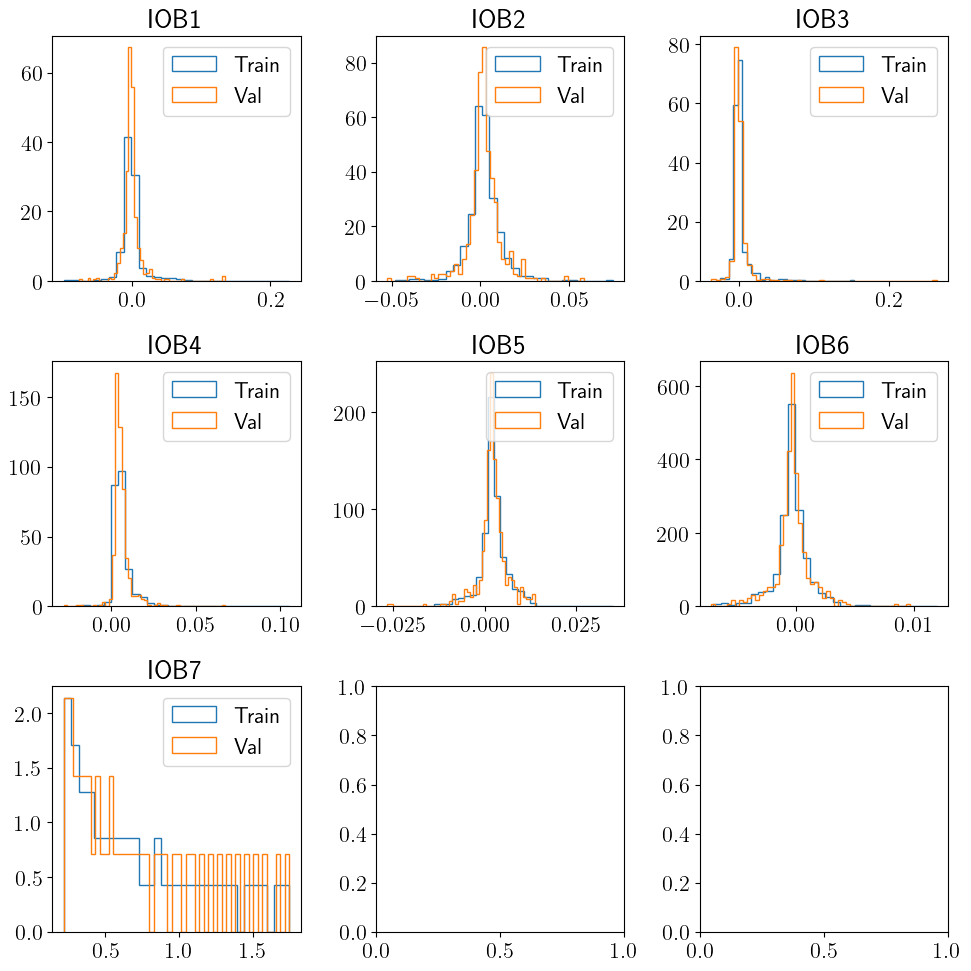

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()